# Pulsed Laser Beam Waist Analysis
Knife-edge measurements to determine beam waist profile along the propagation axis.

In [16]:
%matplotlib inline
import importlib
import pulsed_laser_waist
importlib.reload(pulsed_laser_waist)
from pulsed_laser_waist import read_pulsed_csv, erf_model, erf_model_flipped
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

## Parameters — edit these before running

In [30]:
# Path to folder containing the diodexx_knife_in_yy_zz.csv files
folder = r"F:\Lab data\20260311\vertical knive edge"

# Minimum number of samples between detected peaks
min_peak_distance = 50

# Minimum peak prominence (None = auto: 5% of each file's signal range)
min_peak_prominence = None

# Set True to plot raw data + detected peaks for every file
plot_peaks = False

# R² threshold below which the flipped ERF is tried
r2_threshold = 0.99

# Physical distance per knife-edge step (µm)
dist = 200  # µm per yy increment

# Initial guess for ERF fit [x0, p_max, w] — None for auto-estimate
erf_p0 = None

## Step 1 — Read CSV files and compute average power per knife position

In [31]:
yy_positions, avg_power, per_file_avgs = read_pulsed_csv(
    folder,
    min_peak_distance=min_peak_distance,
    min_peak_prominence=min_peak_prominence,
    plot=plot_peaks
)

diode80_knife_in_00_0.csv  ->  20 peaks,  mean peak power = 1.5839
diode80_knife_in_00_1.csv  ->  20 peaks,  mean peak power = 1.5840
diode80_knife_in_00_2.csv  ->  20 peaks,  mean peak power = 1.5841
diode80_knife_in_00_3.csv  ->  20 peaks,  mean peak power = 1.5842
diode80_knife_in_00_4.csv  ->  20 peaks,  mean peak power = 1.5842
diode80_knife_in_00_5.csv  ->  20 peaks,  mean peak power = 1.5841
diode80_knife_in_00_6.csv  ->  20 peaks,  mean peak power = 1.5844
diode80_knife_in_00_7.csv  ->  20 peaks,  mean peak power = 1.5844
diode80_knife_in_00_8.csv  ->  20 peaks,  mean peak power = 1.5845
diode80_knife_in_00_9.csv  ->  20 peaks,  mean peak power = 1.5846
diode80_knife_in_01_0.csv  ->  20 peaks,  mean peak power = 1.5822
diode80_knife_in_01_1.csv  ->  20 peaks,  mean peak power = 1.5824
diode80_knife_in_01_2.csv  ->  20 peaks,  mean peak power = 1.5826
diode80_knife_in_01_3.csv  ->  20 peaks,  mean peak power = 1.5827
diode80_knife_in_01_4.csv  ->  20 peaks,  mean peak power = 1.

## Step 2 — Plot average power vs knife position

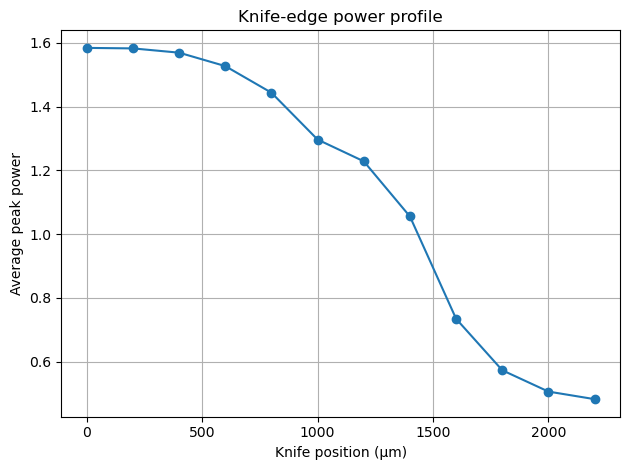

In [32]:
x_pos = np.array(yy_positions) * dist

fig, ax = plt.subplots()
ax.plot(x_pos, avg_power, 'o-')
ax.set_xlabel('Knife position (µm)')
ax.set_ylabel('Average peak power')
ax.set_title('Knife-edge power profile')
ax.grid(True)
plt.tight_layout()
plt.show()

## Step 3 — Fit knife-edge data to error function

Auto p0: x0=1413.8 µm, p_max=1.1021, w=422.7 µm, offset=0.4822
Standard ERF R² = -3.7271 < 0.99, trying flipped ERF...
Model     : Flipped ERF
R²        = 0.94064
x0        = 1413.76 µm
P_max     = 1.1021
w         = 422.65 µm  (beam waist)
offset    = 0.4822  (fitted noise floor)


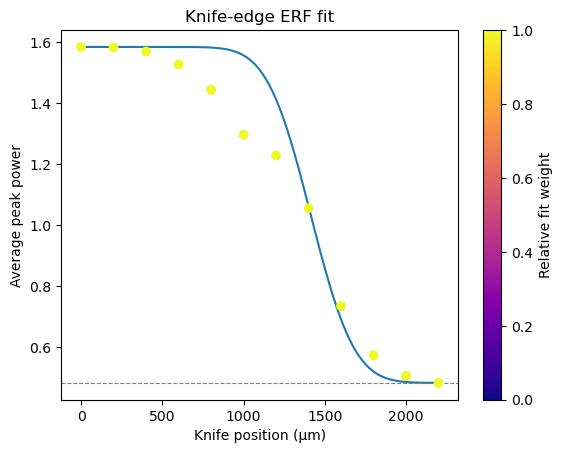

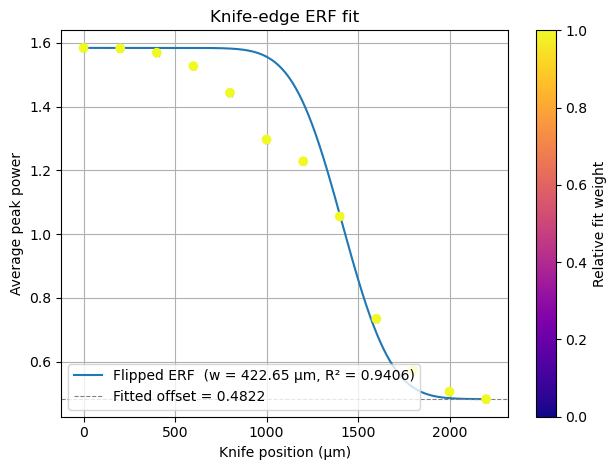

In [38]:
x = np.array(yy_positions, dtype=float) * dist
y = np.array(avg_power,    dtype=float)

# --- Smart initial guess from the data shape ---
y_min, y_max  = y.min(), y.max()
y_range       = y_max - y_min
y_mid         = y_min + 0.5 * y_range
y_16          = y_min + 0.16 * y_range
y_84          = y_min + 0.84 * y_range

# Sort by x so np.interp works (data may be unordered)
sort_idx = np.argsort(x)
xs, ys   = x[sort_idx], y[sort_idx]

# x0: x where y crosses the midpoint
x0_guess = float(np.interp(y_mid, ys if ys[0] < ys[-1] else ys[::-1],
                            xs    if ys[0] < ys[-1] else xs[::-1]))

# w: half the 16%–84% transition width  (≈ 1 beam waist)
x_16 = float(np.interp(y_16, ys if ys[0] < ys[-1] else ys[::-1],
                         xs   if ys[0] < ys[-1] else xs[::-1]))
x_84 = float(np.interp(y_84, ys if ys[0] < ys[-1] else ys[::-1],
                         xs   if ys[0] < ys[-1] else xs[::-1]))
w_guess = abs(x_84 - x_16) / 2

if erf_p0 is None:
    p0 = [x0_guess, y_range, w_guess, y_min]
    print(f'Auto p0: x0={x0_guess:.1f} µm, p_max={y_range:.4f}, w={w_guess:.1f} µm, offset={y_min:.4f}')
else:
    p0 = erf_p0

bounds = ([-np.inf, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf])

# x position measurement uncertainty (µm)
x_uncertainty = 10.0

# Slope-based weight parameters
min_weight     = 1  # Minimum relative weight (0 to 1) for flat regions
weight_falloff = 0.3

def erf_derivative(x, x0, w):
    return np.exp(-2 * (x - x0)**2 / w**2)

def odr_erf(beta, x):
    x0, p_max, w, offset = beta
    return erf_model(x, x0, p_max, w, offset)

def odr_erf_flipped(beta, x):
    x0, p_max, w, offset = beta
    return erf_model_flipped(x, x0, p_max, w, offset)

def run_odr(odr_fn, x, y, p0, sx, sy):
    data   = RealData(x, y, sx=sx, sy=sy)
    result = ODR(data, Model(odr_fn), beta0=p0).run()
    r2     = r2_score(y, odr_fn(result.beta, x))
    return result.beta, r2

def best_fit_cf(model, x, y, p0, bounds):
    try:
        popt, _ = curve_fit(model, x, y, p0=p0, bounds=bounds)
        return popt, r2_score(y, model(x, *popt))
    except RuntimeError:
        return None, -np.inf

# --- Pass 1: unweighted curve_fit to estimate x0 and w ---
popt, r2 = best_fit_cf(erf_model, x, y, p0, bounds)
popt_f, r2_f = best_fit_cf(erf_model_flipped, x, y, p0, bounds)
if r2_f > r2:
    popt, r2 = popt_f, r2_f

# --- Pass 2: ODR with x uncertainty + slope-based y weights ---
x0_est, _, w_est, _ = popt
slope_weights = erf_derivative(x, x0_est, w_est) ** weight_falloff
slope_weights = min_weight + (1.0 - min_weight) * slope_weights

sx = np.full_like(x, x_uncertainty)
sy = 1.0 / slope_weights

popt, r2 = run_odr(odr_erf, x, y, p0, sx, sy)
if r2 < r2_threshold:
    print(f'Standard ERF R² = {r2:.4f} < {r2_threshold}, trying flipped ERF...')
    popt_f, r2_f = run_odr(odr_erf_flipped, x, y, p0, sx, sy)
    if r2_f > r2:
        model_used, popt, r2 = 'Flipped ERF', popt_f, r2_f
    else:
        model_used = 'Standard ERF'
else:
    model_used = 'Standard ERF'

x0_fit, p_max_fit, w_fit, offset_fit = popt
print(f'Model     : {model_used}')
print(f'R²        = {r2:.5f}')
print(f'x0        = {x0_fit:.2f} µm')
print(f'P_max     = {p_max_fit:.4f}')
print(f'w         = {w_fit:.2f} µm  (beam waist)')
print(f'offset    = {offset_fit:.4f}  (fitted noise floor)')

fit_fn = odr_erf if model_used == 'Standard ERF' else odr_erf_flipped
x_fine = np.linspace(x.min(), x.max(), 500)
y_fit  = fit_fn(popt, x_fine)

fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=slope_weights, cmap='plasma', vmin=0, vmax=1, zorder=5)
plt.colorbar(sc, ax=ax, label='Relative fit weight')
ax.errorbar(x, y, xerr=x_uncertainty, fmt='none', color='gray', alpha=0.5, capsize=3, zorder=4)
ax.plot(x_fine, y_fit, label=f'{model_used}  (w = {w_fit:.2f} µm, R² = {r2:.4f})')
ax.axhline(offset_fit, color='gray', linestyle='--', linewidth=0.8, label=f'Fitted offset = {offset_fit:.4f}')
ax.set_xlabel('Knife position (µm)')
ax.set_ylabel('Average peak power')
ax.set_title('Knife-edge ERF fit')
ax.legend(loc='lower left')
ax.grid(True)
plt.tight_layout()
plt.show()